## Predictive Maintenace

For this part of the project, we will use two types of machine learning to predict machine breakdowns before they occur:”

- Classification: using different pre-breakdown time windows
- Regression

## 1. Classification

In [1]:
import pandas as pd
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
import joblib


In [2]:

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.decomposition import PCA


In [3]:
df_scada=pd.read_csv("datasets/scada_data.csv")

In [4]:
df_scada.head(3)

,DateTime,Time,Error,WEC: ava. windspeed,WEC: max. windspeed,WEC: min. windspeed,WEC: ava. Rotation,WEC: max. Rotation,WEC: min. Rotation,WEC: ava. Power,...,Rectifier cabinet temp.,Yaw inverter cabinet temp.,Fan inverter cabinet temp.,Ambient temp.,Tower temp.,Control cabinet temp.,Transformer temp.,RTU: ava. Setpoint 1,Inverter averages,Inverter std dev
0,5/1/2014 0:00,1398920448,0,6.9,9.4,2.9,0.0,0.02,0.0,0,...,24,20,25,12,14,24,34,2501,25.272728,1.103713
1,5/1/2014 0:09,1398920960,0,5.3,8.9,1.6,0.0,0.01,0.0,0,...,24,20,25,12,14,24,34,2501,25.272728,1.103713
2,5/1/2014 0:20,1398921600,0,5.0,9.5,1.4,0.0,0.04,0.0,0,...,24,20,25,12,14,24,34,2501,25.272728,1.103713


### 1.1 Dataset Preparation for the Model with All Features

In [5]:
scada_anomaly = df_scada.copy()
scada_anomaly['DateTime']=pd.to_datetime(scada_anomaly['DateTime'])
scada_anomaly['target'] = ( scada_anomaly['Error'] != 0).astype(int)

scada_anomaly.loc[scada_anomaly['Error'] != 0, 'target'] = 1
scada_anomaly['target'].value_counts()

target
0    48727
1      300
Name: count, dtype: int64

In [6]:
scada_anomaly['Error'].value_counts()

Error
0      48727
246      164
10        35
20        18
50        18
90        14
30        13
70        10
80         9
40         9
60         9
100        1
Name: count, dtype: int64

In [7]:
for col in ['target_30min', 'target_2h', 'target_12h', 'target_24h']:
    scada_anomaly[col] = 0

In [8]:
failure_times = scada_anomaly.loc[scada_anomaly['target'] == 1, 'DateTime']

for t in failure_times:

    # 24h
    mask_24h = (
        (scada_anomaly['DateTime'] >= t - pd.Timedelta(hours=24)) &
        (scada_anomaly['DateTime'] < t)
    )
    scada_anomaly.loc[mask_24h, 'target_24h'] = 1

    # 12h 
    mask_12h = (
        (scada_anomaly['DateTime'] >= t - pd.Timedelta(hours=12)) &
        (scada_anomaly['DateTime'] < t)
    )
    scada_anomaly.loc[mask_12h, 'target_12h'] = 1

    # 2h 
    mask_2h = (
        (scada_anomaly['DateTime'] >= t - pd.Timedelta(hours=2)) &
        (scada_anomaly['DateTime'] < t)
    )
    scada_anomaly.loc[mask_2h, 'target_2h'] = 1
      # 24h 
    mask_30min = (
        (scada_anomaly['DateTime'] >= t - pd.Timedelta(minutes=30)) &
        (scada_anomaly['DateTime'] < t)
    )
    scada_anomaly.loc[mask_30min, 'target_30min'] = 1

In [9]:
print("0h    :", scada_anomaly['target'].sum())
print("30min    :", scada_anomaly['target_30min'].sum())
print("2h     :", scada_anomaly['target_2h'].sum())
print("12h    :", scada_anomaly['target_12h'].sum())
print("24h    :", scada_anomaly['target_24h'].sum())


0h    : 300
30min    : 395
2h     : 713
12h    : 2683
24h    : 4840


In [10]:
scada_anomaly['target_12h'].value_counts()

target_12h
0    46344
1     2683
Name: count, dtype: int64

In [11]:
premiere_panne = failure_times.iloc[0]

fenetre = scada_anomaly[
    (scada_anomaly['DateTime'] >= premiere_panne - pd.Timedelta(hours=1)) &
    (scada_anomaly['DateTime'] <= premiere_panne + pd.Timedelta(minutes=5))
][['DateTime', 'Error', 'target', 'target_30min']]

print(fenetre)
print(f"\nPanne à : {premiere_panne}")

              DateTime  Error  target  target_30min
54 2014-05-01 11:29:00     80       1             0

Panne à : 2014-05-01 11:29:00


In [12]:
for col in ['target', 'target_30min', 'target_2h', 'target_12h', 'target_24h']:
    counts = scada_anomaly[col].value_counts()
    pct = scada_anomaly[col].mean() * 100
    print(f"{col}: {counts.to_dict()} → {pct:.2f}% de pannes")

target: {0: 48727, 1: 300} → 0.61% de pannes
target_30min: {0: 48632, 1: 395} → 0.81% de pannes
target_2h: {0: 48314, 1: 713} → 1.45% de pannes
target_12h: {0: 46344, 1: 2683} → 5.47% de pannes
target_24h: {0: 44187, 1: 4840} → 9.87% de pannes


In [13]:
scada_anomaly.to_csv("df_final.csv", index=False)

### 1.2 Pre-failure Window: 2h

In [14]:
scada_anomaly['target_2h'].value_counts()

target_2h
0    48314
1      713
Name: count, dtype: int64

In [15]:
df_binary = scada_anomaly[scada_anomaly['target_2h'].isin([0, 1])].copy() # on prend que la classse normale et la classe qui correpond à le pré-panne

scada_anomaly= df_binary.copy()

scada_anomaly_numeric=scada_anomaly.select_dtypes(include=[np.number])
features=[]
for col in scada_anomaly_numeric.columns :
    if col not in  ['target','target_failure','target_30min', 'target_12h', 'target_2h', 'target_24h', 'Error', 'DateTime', 'Time'] :
        features.append(col)
print(f"   Features sélectionnées : {len(features)}")

   Features sélectionnées : 63


In [16]:

X=scada_anomaly[features].fillna(0)
y=scada_anomaly['target_2h']

print(f"   X shape : {X.shape}")
print(f"   y shape : {y.shape}")


   X shape : (49027, 63)
   y shape : (49027,)


In [17]:
split_idx=int(len(scada_anomaly)*0.7)

X_train, X_test=X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test=y.iloc[:split_idx], y.iloc[split_idx:]

print(f"train : {len(X_train)}, test : {len(X_test)} ")


train : 34318, test : 14709 


In [18]:

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(X_test_scaled)

[[ 0.92090302  0.71379894 -0.03046936 ...  0.43937039 -1.57587317
  -0.44126389]
 [ 0.53553616  0.56224866 -0.03247087 ...  0.43937039 -1.57587317
  -0.44126389]
 [ 0.23910016  0.21584852 -0.03447237 ...  0.43937039 -1.66391191
  -0.51885637]
 ...
 [-0.67985156 -0.45530207 -0.04528052 ...  0.43937039 -1.26773919
   1.05673579]
 [-0.70949513 -0.47695206 -0.04488022 ...  0.43937039 -1.35577747
   1.03016618]
 [-0.50198984 -0.60685214 -0.04247841 ...  0.43937039 -1.39979661
   0.94071005]]


In [19]:
models = {
    'RandomForest'     : RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1),
    'GradientBoosting' : GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42),
    'LightGBM'         : LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=31, random_state=42, verbose=-1)
}

models_with_class_weight = {
    'RandomForest'     : RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1),
    'GradientBoosting' : GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42),
    'LightGBM'         : LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=31, class_weight='balanced', random_state=42, verbose=-1)
}

sampling_methods = {
    'SMOTE'              : SMOTE(random_state=42),
    'RandomUnderSampler' : RandomUnderSampler(random_state=42),
}

COLORS = {
    'RandomForest'     : '#E53935',
    'GradientBoosting' : '#27AE60',
    'LightGBM'         : '#1565C0'
}

results  = []
roc_data = [] 
cms      = {}  


In [20]:

def evaluate(method_name, model_name, model, X_tr, y_tr):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    report    = classification_report(y_test, y_pred, target_names=['Normal', 'Panne'], output_dict=True)
    auc_score = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    cm        = confusion_matrix(y_test, y_pred)

    label = f"{method_name}\n{model_name}"
    roc_data.append({'label': label, 'fpr': fpr, 'tpr': tpr, 'auc': auc_score, 'model': model_name})
    cms[label] = cm

    results.append({
        'Méthode'  : method_name,
        'Modèle'   : model_name,
        'Precision': round(report['Panne']['precision'], 3),
        'Recall'   : round(report['Panne']['recall'], 3),
        'F1'       : round(report['Panne']['f1-score'], 3),
        'AUC'      : round(auc_score, 3)
    })
    return model

In [21]:
trained_models = {}

# SMOTE + RandomUnderSampler
for method_name, sampler in sampling_methods.items():
    X_res, y_res = sampler.fit_resample(X_train_scaled, y_train)
    for model_name, model in models.items():
        print(f"   {method_name} + {model_name}...")
        trained_models[(method_name, model_name)] = evaluate(method_name, model_name, model, X_res, y_res)

# class_weight
for model_name, model in models_with_class_weight.items():
    print(f"    class_weight + {model_name}...")
    trained_models[('class_weight', model_name)] = evaluate('class_weight', model_name, model, X_train_scaled, y_train)

   SMOTE + RandomForest...
   SMOTE + GradientBoosting...
   SMOTE + LightGBM...


/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   RandomUnderSampler + RandomForest...
   RandomUnderSampler + GradientBoosting...
   RandomUnderSampler + LightGBM...
    class_weight + RandomForest...


/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


    class_weight + GradientBoosting...
    class_weight + LightGBM...


/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [22]:
df_results = pd.DataFrame(results).sort_values(['F1'], ascending=False)
best = df_results.iloc[0]

best_model = trained_models[(best['Méthode'], best['Modèle'])]
joblib.dump(best_model, "best_model.pkl")
print(f"Modèle sauvegardé : {best['Méthode']} + {best['Modèle']}")

Modèle sauvegardé : class_weight + GradientBoosting


In [23]:
joblib.dump(best_model, 'best_model_final.pkl')  

['best_model_final.pkl']

In [24]:
model  = joblib.load('best_model_final.pkl')

print(type(model))

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


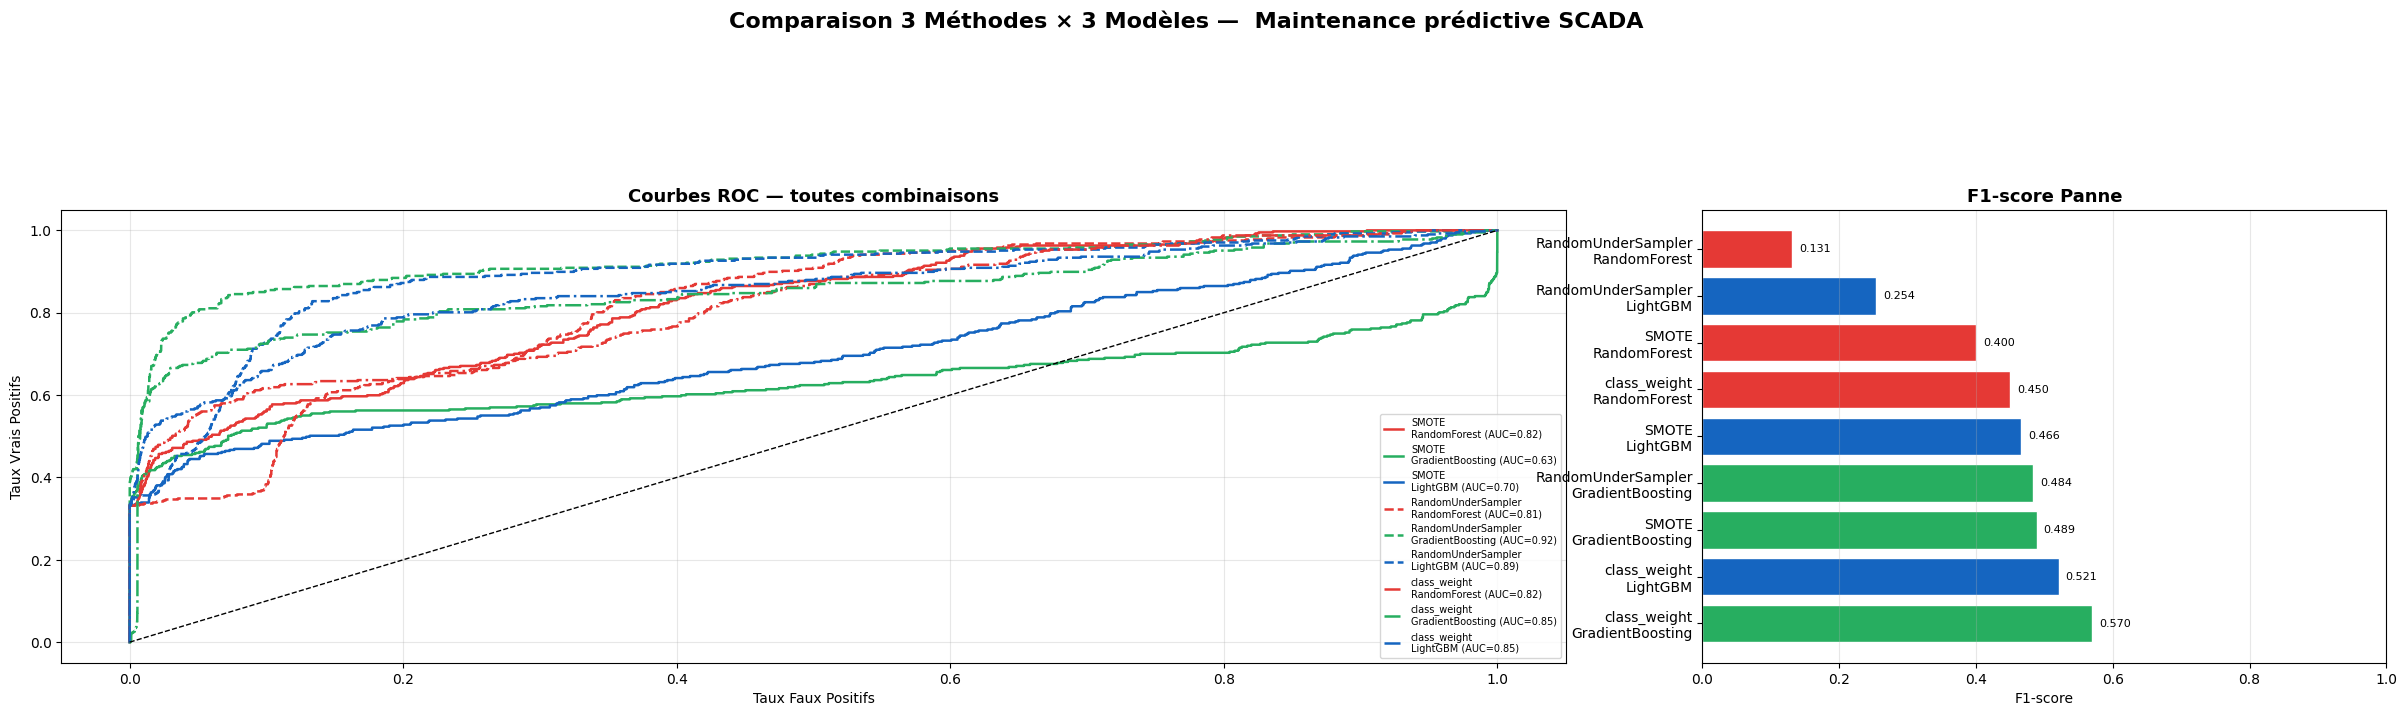

In [25]:
fig = plt.figure(figsize=(30, 20))
fig.suptitle("Comparaison 3 Méthodes × 3 Modèles —  Maintenance prédictive SCADA",
             fontsize=16, fontweight='bold', y=0.98)

# ── 1. Courbes ROC ──────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(3, 3, (1, 2))  # occupe 2 colonnes
ax_roc.set_title("Courbes ROC — toutes combinaisons", fontsize=13, fontweight='bold')

linestyles = {'SMOTE': '-', 'RandomUnderSampler': '--', 'class_weight': '-.'}

for d in roc_data:
    method = d['label'].split('\n')[0]
    ax_roc.plot(d['fpr'], d['tpr'],
                color=COLORS[d['model']],
                linestyle=linestyles[method],
                linewidth=1.8,
                label=f"{d['label']} (AUC={d['auc']:.2f})")

ax_roc.plot([0,1],[0,1], 'k--', linewidth=1)
ax_roc.set_xlabel("Taux Faux Positifs")
ax_roc.set_ylabel("Taux Vrais Positifs")
ax_roc.legend(fontsize=7, loc='lower right')
ax_roc.grid(True, alpha=0.3)

# ── 2. Barplot F1 ───────────────────────────────────────────────────────────
ax_f1 = fig.add_subplot(3, 3, 3)
ax_f1.set_title("F1-score Panne", fontsize=13, fontweight='bold')

df_plot = df_results.copy()
df_plot['label'] = df_plot['Méthode'] + '\n' + df_plot['Modèle']
colors_bar = [COLORS[m] for m in df_plot['Modèle']]

bars = ax_f1.barh(df_plot['label'], df_plot['F1'], color=colors_bar, edgecolor='white')
ax_f1.set_xlabel("F1-score")
ax_f1.set_xlim(0, 1)
for bar, val in zip(bars, df_plot['F1']):
    ax_f1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
               f'{val:.3f}', va='center', fontsize=8)
ax_f1.grid(True, alpha=0.3, axis='x')

### 1.3 Redundancy Features 

#### Method : Scree Plot 

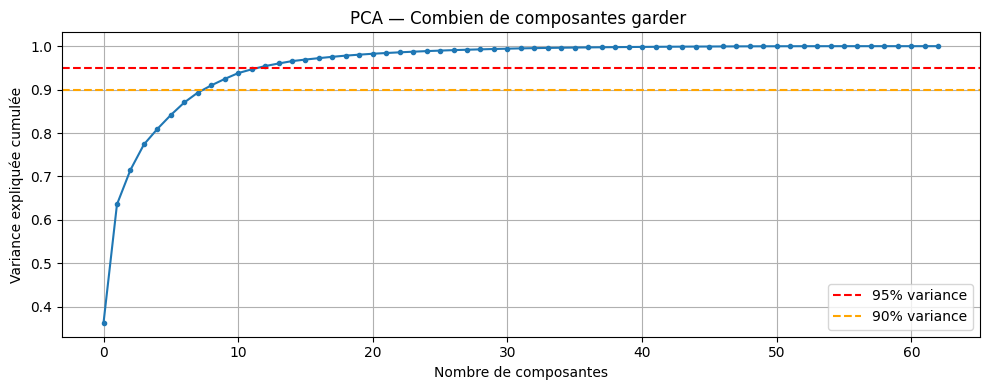

In [26]:
pca_check = PCA()
pca_check.fit(X_train_scaled)

variance_cumulee = np.cumsum(pca_check.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.plot(variance_cumulee, marker='o', markersize=3)
plt.axhline(0.95, color='red',   linestyle='--', label='95% variance')
plt.axhline(0.90, color='orange', linestyle='--', label='90% variance')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée')
plt.title('PCA — Combien de composantes garder ')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
for seuil in [0.90, 0.95, 0.99]:
    n = np.argmax(variance_cumulee >= seuil) + 1
    print(f"{seuil*100:.0f}% variance → {n} composantes sur 63")

90% variance → 9 composantes sur 63
95% variance → 13 composantes sur 63
99% variance → 27 composantes sur 63


In [28]:
def run_experiment_pca(target_col, scada_anomaly, features,
                       split_ratio=0.7, variance=0.95, use_pca=True):
    """
    Pipeline complet avec PCA optionnel.
    variance : % de variance à conserver (0.90, 0.95, 0.99)
    use_pca  : True/False pour comparer avec/sans
    """
    print(f"\n{'='*60}")
    print(f"  TARGET : {target_col} | PCA : {use_pca} ({variance*100:.0f}%)")
    print(f"{'='*60}")

    # 1. Split
    X = scada_anomaly[features].fillna(0)
    y = scada_anomaly[target_col]

    split_idx  = int(len(scada_anomaly) * split_ratio)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # 2. Normalisation
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # 3. PCA (optionnel)
    if use_pca:
        pca = PCA(n_components=variance, random_state=42)
        X_train_sc = pca.fit_transform(X_train_sc)
        X_test_sc  = pca.transform(X_test_sc)
        print(f"  PCA : {X_train.shape[1]} features → "
              f"{pca.n_components_} composantes")
    else:
        print(f"  Features : {X_train.shape[1]} (sans PCA)")

    # 4. Modèles
    models = {
        'RandomForest'     : RandomForestClassifier(n_estimators=300, max_depth=6,
                                                     random_state=42, n_jobs=-1),
        'GradientBoosting' : GradientBoostingClassifier(n_estimators=300,
                                                         learning_rate=0.05,
                                                         max_depth=6, random_state=42),
        'LightGBM'         : LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                             max_depth=6, random_state=42, verbose=-1)
    }
    models_cw = {
        'RandomForest'     : RandomForestClassifier(n_estimators=300, max_depth=6,
                                                     class_weight='balanced',
                                                     random_state=42, n_jobs=-1),
        'GradientBoosting' : GradientBoostingClassifier(n_estimators=300,
                                                         learning_rate=0.05,
                                                         max_depth=6, random_state=42),
        'LightGBM'         : LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                             max_depth=6, class_weight='balanced',
                                             random_state=42, verbose=-1)
    }
    sampling_methods = {
        'SMOTE'              : SMOTE(random_state=42),
        'RandomUnderSampler' : RandomUnderSampler(random_state=42),
    }

    results = []
    probas   = {}  

    def evaluate(method_name, model_name, model, X_tr, y_tr):
        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_test_sc)
        y_proba = model.predict_proba(X_test_sc)[:, 1]
        report  = classification_report(y_test, y_pred,
                                        output_dict=True, zero_division=0)
        auc     = roc_auc_score(y_test, y_proba)

        label = f"{method_name}||{model_name}"
        probas[label] = y_proba
        results.append({
            'Target'    : target_col,
            'PCA'       : f'{use_pca}',
            'Méthode'   : method_name,
            'Modèle'    : model_name,
            'Precision' : round(report['1']['precision'], 3),
            'Recall'    : round(report['1']['recall'], 3),
            'F1'        : round(report['1']['f1-score'], 3),
            'AUC'       : round(auc, 3)
        })

    for method_name, sampler in sampling_methods.items():
        X_res, y_res = sampler.fit_resample(X_train_sc, y_train)
        for model_name, model in models.items():
            print(f"  ⏳ {method_name} + {model_name}...")
            evaluate(method_name, model_name, model, X_res, y_res)

    for model_name, model in models_cw.items():
        print(f"  ⏳ class_weight + {model_name}...")
        evaluate('class_weight', model_name, model, X_train_sc, y_train)

    df = pd.DataFrame(results).sort_values('F1', ascending=False)
    best = df.iloc[0]
    best_label  = f"{best['Méthode']}||{best['Modèle']}"
    best_proba  = probas[best_label]
    print(f"\n  ✅ Meilleur : {best['Méthode']} + {best['Modèle']} "
          f"→ Recall={best['Recall']} | F1={best['F1']} | AUC={best['AUC']}")
    return df, best_label, y_test


# ============================================================
# COMPARER AVEC ET SANS PCA sur target_2h uniquement d'abord
# ============================================================
df_sans_pca, y_proba_sans, y_test = run_experiment_pca(
    'target_2h', scada_anomaly, features, use_pca=False
)
df_avec_pca, y_proba_avec, _      = run_experiment_pca(
    'target_2h', scada_anomaly, features, use_pca=True, variance=0.95
)

# Tableau comparatif
best_sans = df_sans_pca.iloc[0]
best_avec = df_avec_pca.iloc[0]
print(f"\n{'='*50}")
print(f"  SANS PCA → F1: {best_sans['F1']} | Recall: {best_sans['Recall']} | AUC: {best_sans['AUC']}")
print(f"  AVEC PCA → F1: {best_avec['F1']} | Recall: {best_avec['Recall']} | AUC: {best_avec['AUC']}")

if best_avec['F1'] > best_sans['F1']:
    print("  → PCA améliore ✅")
    y_proba_final = y_proba_avec
else:
    print("  → Garder sans PCA ✅")
    y_proba_final = y_proba_sans



  TARGET : target_2h | PCA : False (95%)
  Features : 63 (sans PCA)
  ⏳ SMOTE + RandomForest...
  ⏳ SMOTE + GradientBoosting...
  ⏳ SMOTE + LightGBM...


/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  ⏳ RandomUnderSampler + RandomForest...
  ⏳ RandomUnderSampler + GradientBoosting...
  ⏳ RandomUnderSampler + LightGBM...
  ⏳ class_weight + RandomForest...


/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  ⏳ class_weight + GradientBoosting...
  ⏳ class_weight + LightGBM...


...

/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  ⏳ RandomUnderSampler + RandomForest...
  ⏳ RandomUnderSampler + GradientBoosting...
  ⏳ RandomUnderSampler + LightGBM...
  ⏳ class_weight + RandomForest...


/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  ⏳ class_weight + GradientBoosting...
  ⏳ class_weight + LightGBM...

  ✅ Meilleur : class_weight + LightGBM → Recall=0.514 | F1=0.575 | AUC=0.872

  SANS PCA → F1: 0.57 | Recall: 0.582 | AUC: 0.851
  AVEC PCA → F1: 0.575 | Recall: 0.514 | AUC: 0.872
  → PCA améliore ✅


/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


There is no significant difference between the model with PCA and without PCA. However, with PCA, the recall decreases, which indicates a loss of information.

In [29]:
# Sauvegarder le modèle final définitivement

joblib.dump(best_sans, 'model_final.pkl')
joblib.dump(scaler,     'scaler_final.pkl')

# Sauvegarder aussi les prédictions test
np.save('y_test.npy',   y_test.values)
np.save('y_proba.npy',  y_proba_sans)

print(" Modèle sauvegardé")
print(f"   Features utilisées : {len(features)}")
print(f"   Target             : target_2h")
print(f"   PCA                : Non")

 Modèle sauvegardé
   Features utilisées : 63
   Target             : target_2h
   PCA                : Non


## 2. Regression : Remaining Useful Life (RUL)

### Sensor Trends 24 Hours Before Failure

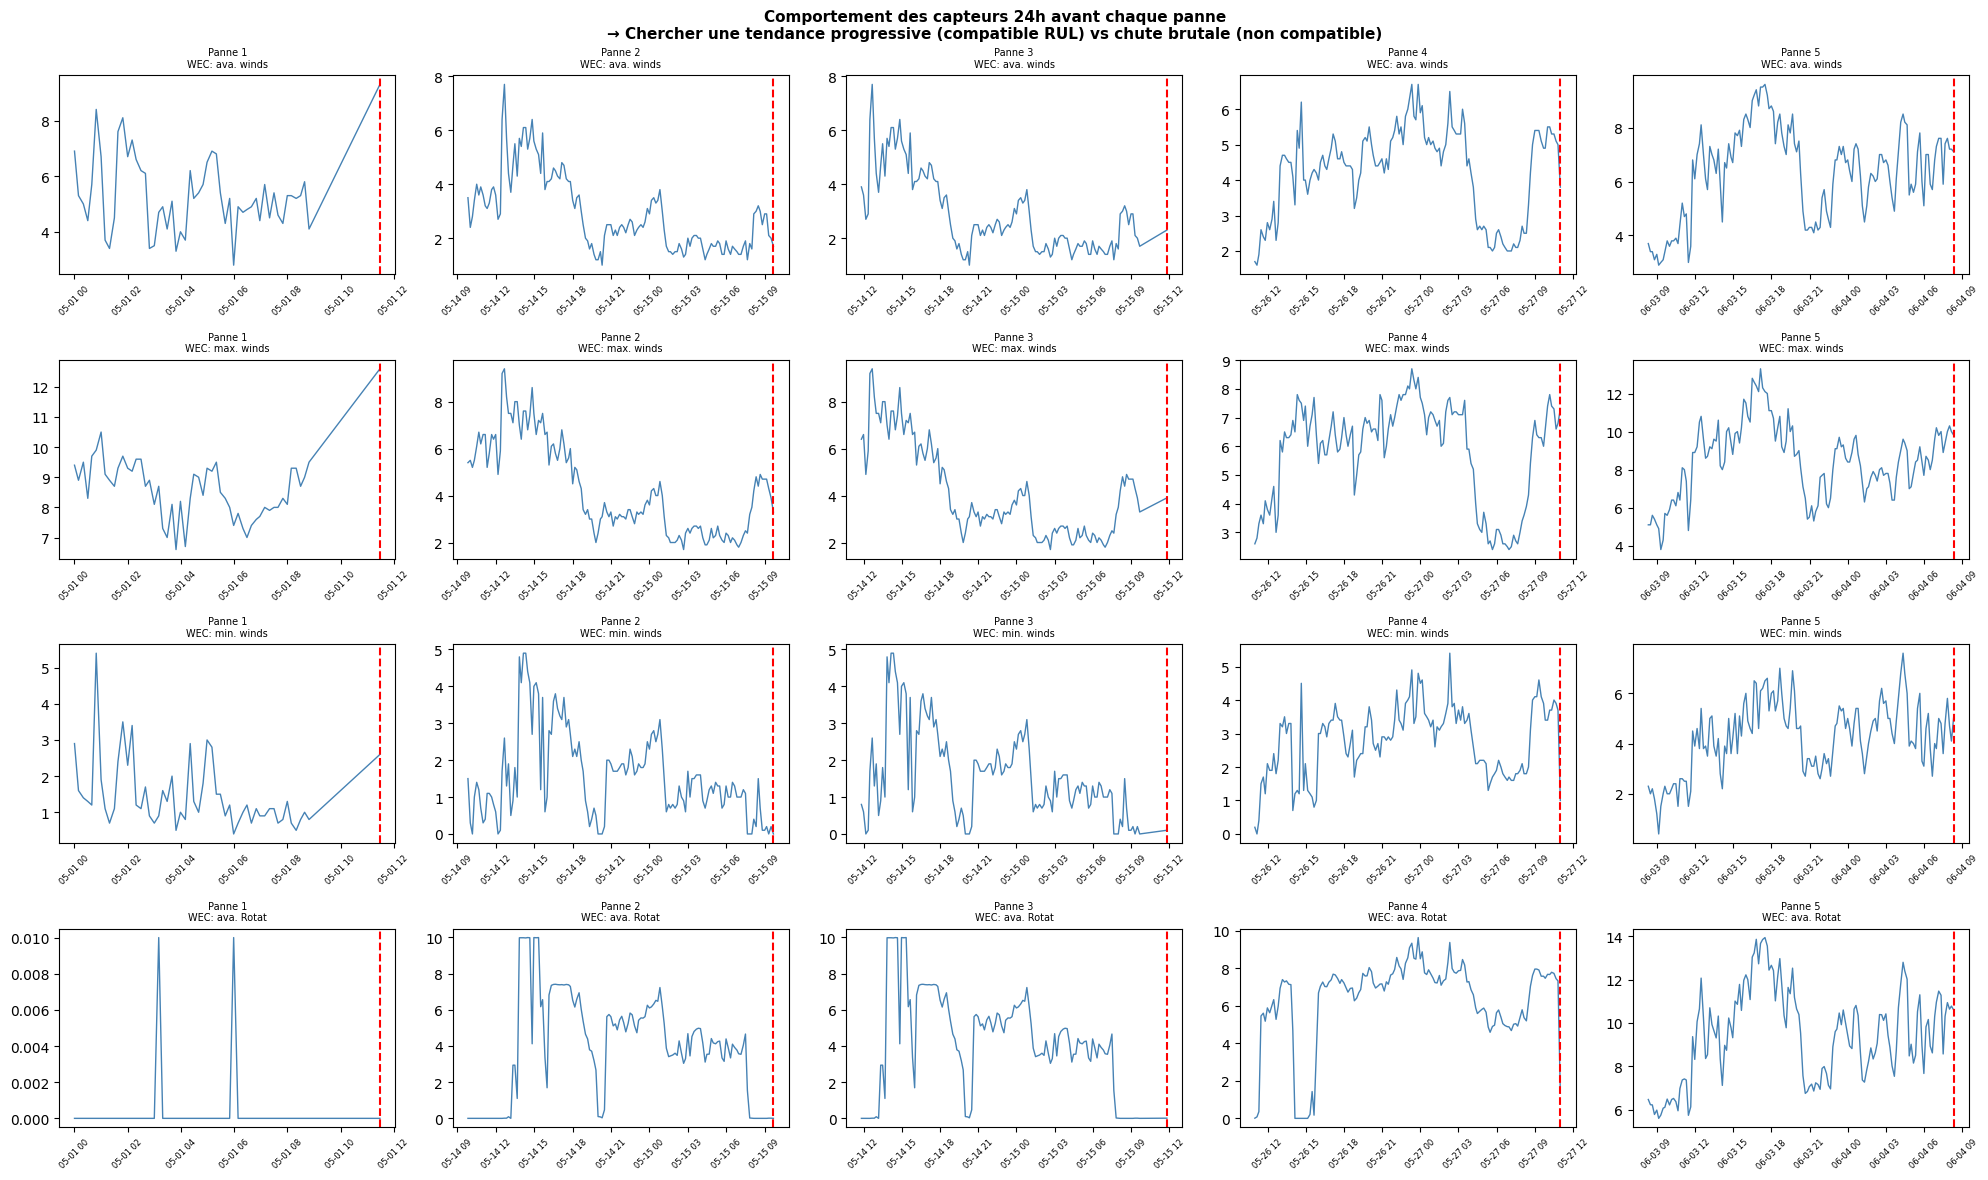

In [30]:
# La question clé : est-ce que vos capteurs "dérivent" 
# progressivement avant la panne ou changent brutalement ?

failure_times = sorted(
    scada_anomaly.loc[scada_anomaly['target'] == 1, 'DateTime']
) # distinguer les temps des pannes et les ordonner

fig, axes = plt.subplots(len(features[:4]), len(failure_times[:5]), 
                          figsize=(20, 12))

for col_idx, capteur in enumerate(features[:4]):
    for pan_idx, t in enumerate(failure_times[:5]):
        
        ax = axes[col_idx][pan_idx]
        
        # Fenêtre 24h avant la panne
        window = scada_anomaly[
            (scada_anomaly['DateTime'] >= t - pd.Timedelta(hours=24)) &
            (scada_anomaly['DateTime'] <= t)
        ]
        
        if len(window) > 0:
            ax.plot(window['DateTime'], window[capteur], 
                    color='steelblue', linewidth=1)
            ax.axvline(t, color='red', linestyle='--', linewidth=1.5)
            ax.set_title(f'Panne {pan_idx+1}\n{capteur[:15]}', fontsize=7)
            ax.tick_params(axis='x', rotation=45, labelsize=6)
        
plt.suptitle("Comportement des capteurs 24h avant chaque panne\n"
             "→ Chercher une tendance progressive (compatible RUL) "
             "vs chute brutale (non compatible)", 
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### Sensor Trends 2 Hours Before Failure

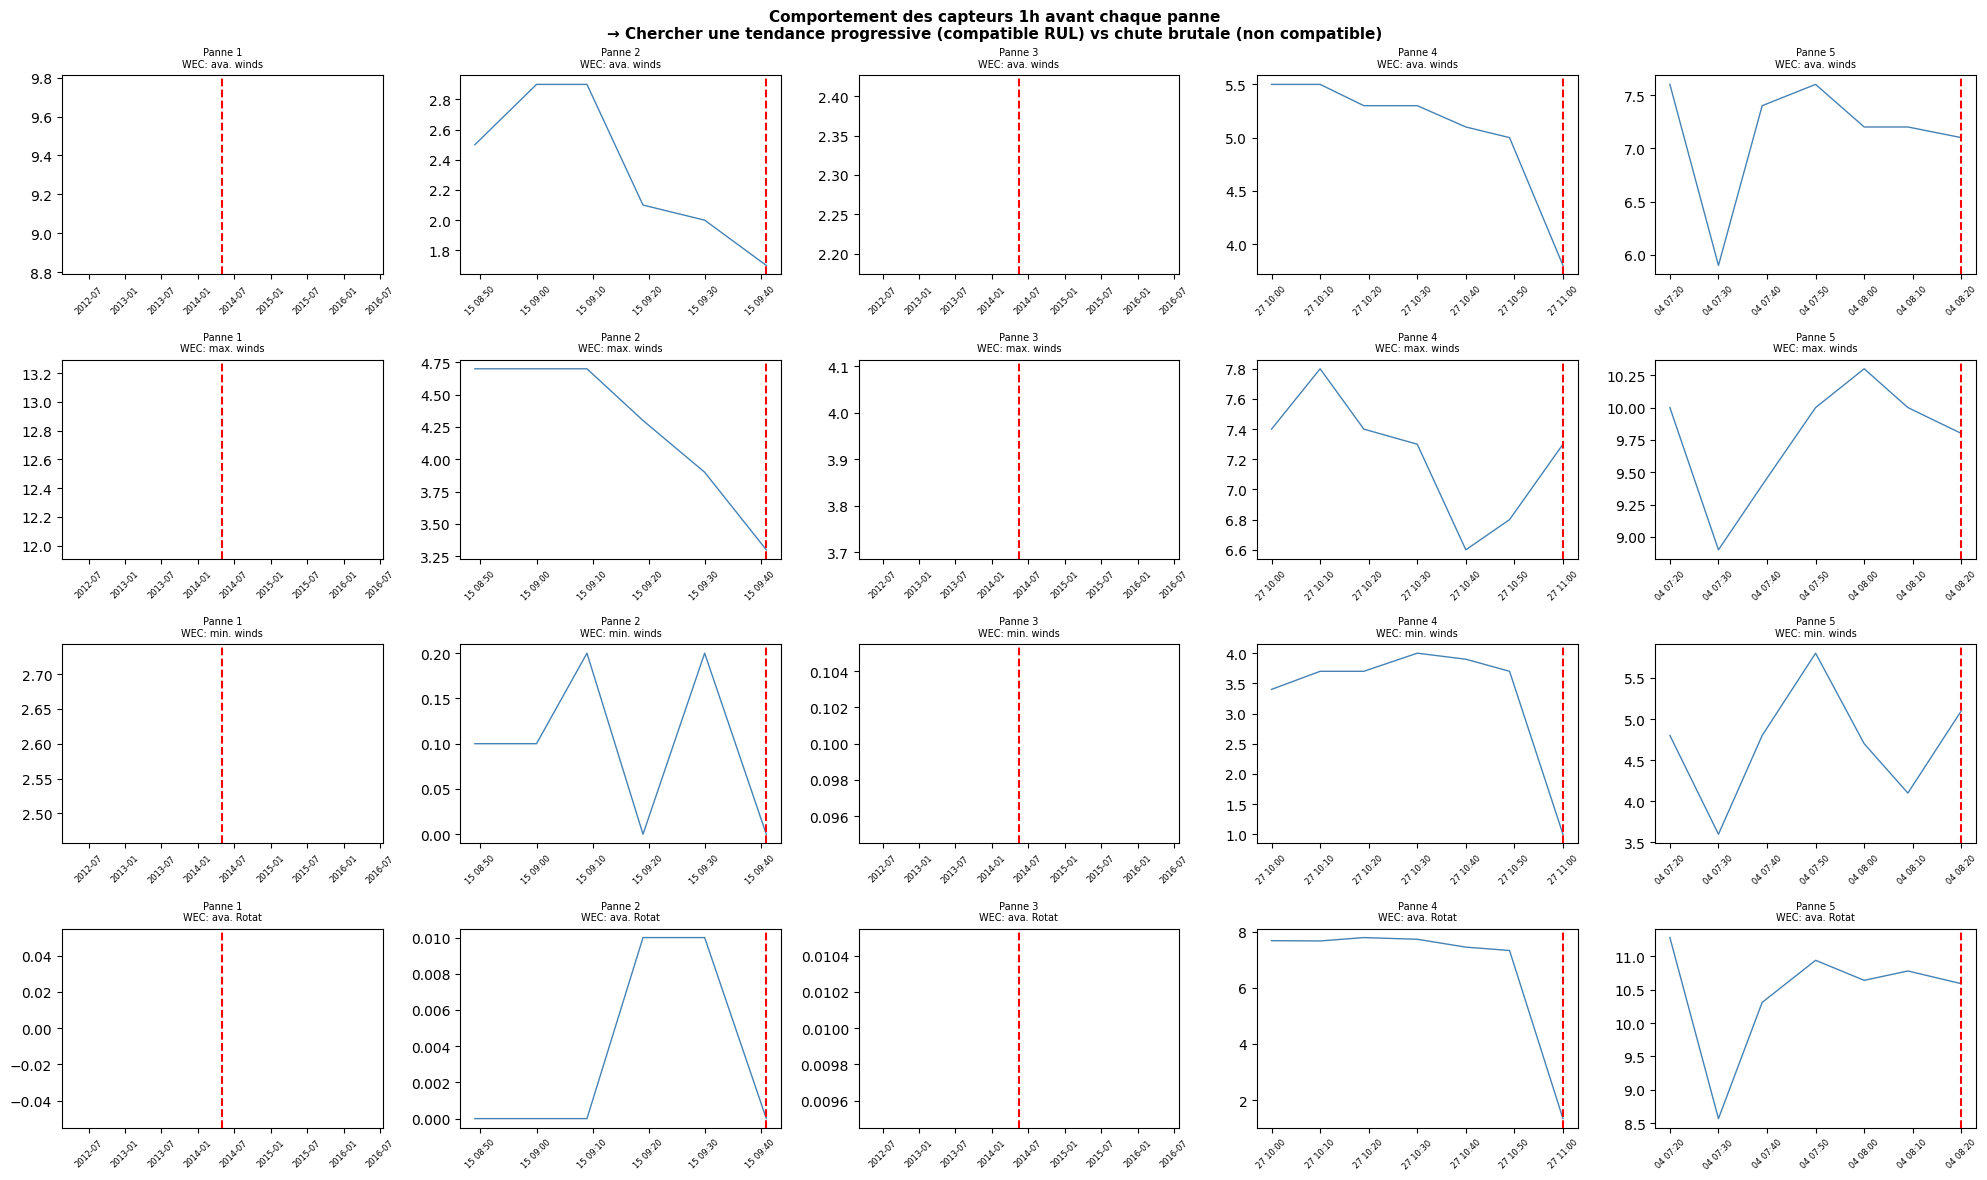

In [31]:
# La question clé : est-ce que vos capteurs "dérivent" 
# progressivement avant la panne ou changent brutalement ?

failure_times = sorted(
    scada_anomaly.loc[scada_anomaly['target'] == 1, 'DateTime']
) # distinguer les temps des pannes et les ordonner

fig, axes = plt.subplots(len(features[:4]), len(failure_times[:5]), 
                          figsize=(20, 12))

for col_idx, capteur in enumerate(features[:4]):
    for pan_idx, t in enumerate(failure_times[:5]):
        
        ax = axes[col_idx][pan_idx]
        
        # Fenêtre 24h avant la panne
        window = scada_anomaly[
            (scada_anomaly['DateTime'] >= t - pd.Timedelta(hours=1)) &
            (scada_anomaly['DateTime'] <= t)
        ]
        
        if len(window) > 0:
            ax.plot(window['DateTime'], window[capteur], 
                    color='steelblue', linewidth=1)
            ax.axvline(t, color='red', linestyle='--', linewidth=1.5)
            ax.set_title(f'Panne {pan_idx+1}\n{capteur[:15]}', fontsize=7)
            ax.tick_params(axis='x', rotation=45, labelsize=6)
        
plt.suptitle("Comportement des capteurs 1h avant chaque panne\n"
             "→ Chercher une tendance progressive (compatible RUL) "
             "vs chute brutale (non compatible)", 
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

RUL on This Dataset → Not Relevant

Three main reasons:

1. Inadequate Sensors
Wind speed and rotation are mainly driven by wind conditions \
They are not directly related to mechanical wear \
→ No clear progressive degradation pattern

2. Highly Concentrated Failures
Failures occur close together in time \
→ Impossible to compute a reliable Remaining Useful Life (RUL) \
→ Time windows overlap significantly

3. Short-Term Signal Only (1–2 Hours) \
Detectable changes appear only 1–2 hours before failure \
RUL requires signals over days or weeks

→ The dataset does not support long-term degradation modeling